Visualizaciones

Sección 1: Evolución temporal del IPC
 
Sección 2: Constituciones y disoluciones en el tiempo  
 
Sección 3: Análisis del impacto COVID-19 (2020-2021)
 
Sección 4: Relación IPC vs actividad empresarial
 
Sección 5: Análisis por territorio
 
Sección 6: Análisis de capital y tipo societario

In [91]:
# Importación de librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Configuración de el estilo de los graficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Configuración para visualizar todas las columnas
pd.set_option('display.max_columns', None)

In [92]:
df_empr_const = pd.read_csv('../files/data_processed/empresas_constituidas.csv')
df_empr_dis = pd.read_csv('../files/data_processed/empresas_disueltas.csv')
df_ipc = pd.read_csv('../files/data_processed/ipc.csv')
df_sectores_ipc = pd.read_csv('../files/data_processed/sectores_ipc.csv')
df_territorio = pd.read_csv('../files/data_processed/territorio.csv')
df_tiempo = pd.read_csv('../files/data_processed/tiempo.csv')
df_tipo_medida = pd.read_csv('../files/data_processed/tipo_medida.csv')

Sección 1 — Evolución del IPC

- Gráfico 1.1 — IPC Índice General Nacional

In [93]:
# 1. Combinar el DataFrame de IPC con las dimensiones de tiempo, sector y tipo de medida
 
df_ipc_completo = df_ipc.merge(df_tiempo, on='id_tiempo', how='inner') \
.merge(df_sectores_ipc, on='id_sector', how='inner') \
.merge(df_tipo_medida, on='id_medida', how='inner') \
.merge(df_territorio, on='id_territorio', how='inner')

# 2. Filtrar para obtener ÚNICAMENTE el Índice General a nivel Nacional
 
df_filtrado = df_ipc_completo[
 
    (df_ipc_completo['nombre_sector'].str.contains('general', case=False, na=False)) &
     (df_ipc_completo['nombre_medida'].str.contains('indice', case=False, na=False)) &
     (df_ipc_completo['nombre_territorio'] == 'nacional')
 
]
 
# 3. Convertir el periodo a formato datetime para que el eje X se ordene y dibuje correctamente
  
if 'fecha' in df_filtrado.columns:
 
    df_filtrado['fecha_dt'] = pd.to_datetime(df_filtrado['fecha'])
 
else:
 
    df_filtrado['fecha_dt'] = pd.to_datetime(df_filtrado['id_tiempo'].astype(str) + '01', format='%Y%m%d')
 
# 4. Ordenar cronológicamente
 
df_filtrado = df_filtrado.sort_values('fecha_dt')


In [94]:
df_ipc_completo.head()

,id_tiempo,id_territorio,id_sector,id_medida,valor_ipc,anio,mes,nombre_mes,nombre_sector,nombre_medida,nombre_territorio
0,202605,1,1,1,102.951,2026,5,mayo,indice_general,indice,nacional
1,202604,1,1,1,102.883,2026,4,abril,indice_general,indice,nacional
2,202603,1,1,1,102.440,2026,3,marzo,indice_general,indice,nacional
3,202602,1,1,1,101.261,2026,2,febrero,indice_general,indice,nacional
4,202601,1,1,1,100.836,2026,1,enero,indice_general,indice,nacional


In [95]:
df_filtrado.head()

,id_tiempo,id_territorio,id_sector,id_medida,valor_ipc,anio,mes,nombre_mes,nombre_sector,nombre_medida,nombre_territorio,fecha_dt
292,200201,1,1,1,58.717,2002,1,enero,indice_general,indice,nacional,2002-01-01
291,200202,1,1,1,58.768,2002,2,febrero,indice_general,indice,nacional,2002-02-01
290,200203,1,1,1,59.253,2002,3,marzo,indice_general,indice,nacional,2002-03-01
289,200204,1,1,1,60.058,2002,4,abril,indice_general,indice,nacional,2002-04-01
288,200205,1,1,1,60.274,2002,5,mayo,indice_general,indice,nacional,2002-05-01


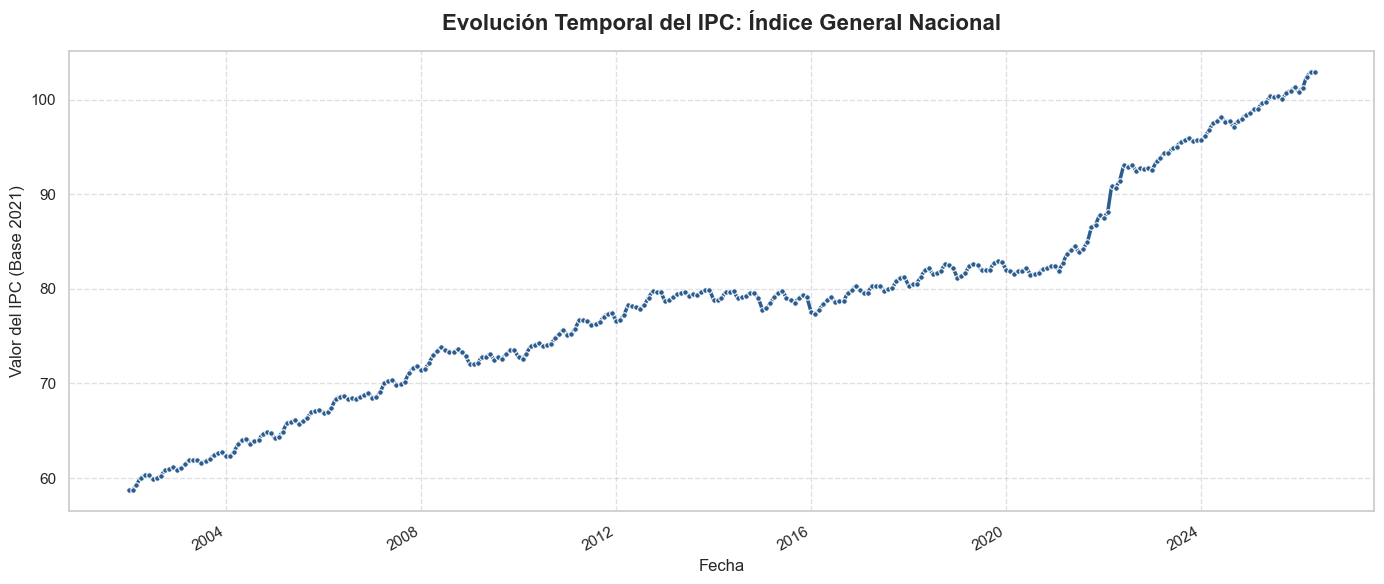

In [96]:
# 5. Construcción del Gráfico
 
plt.figure(figsize=(14, 6))
 
sns.lineplot(
 
    data=df_filtrado,
 
    x='fecha_dt',
 
    y='valor_ipc',
 
    linewidth=2.5,
 
    color='#2b5c8f',
 
    marker='o',
 
    markersize=4
 
)
 
# Personalización estética limpia
 
plt.title('Evolución Temporal del IPC: Índice General Nacional', fontsize=16, fontweight='bold', pad=15)
 
plt.xlabel('Fecha', fontsize=12)
 
plt.ylabel('Valor del IPC (Base 2021)', fontsize=12) # Ajusta la base según corresponda a tu dataset del INE
 
plt.grid(True, linestyle='--', alpha=0.6)
 
# Ajustar formato de fechas en el eje X para que no se amontone
 
plt.gcf().autofmt_xdate()
 
plt.tight_layout()
 
plt.show()

Análisis del Gráfico: Evolución del IPC Índice General Nacional

Lectura general

El gráfico muestra el Índice de Precios al Consumo (IPC) nacional de España con base 2021=100, cubriendo el periodo 2002–2026. La línea呈现a una tendencia ascendente sostenida a lo largo de todo el periodo, con fases diferenciadas:

Fases identificadas
Periodo	Comportamiento	Posible interpretación
- 2002–2008	Crecimiento sostenido	Boom económico, crédito fácil, subida de precios de vivienda y consumo
- 2008–2013	Meseta / leve corrección	Crisis financiera, recortes, deflación intermitente. El IPC se estanca
- 2014–2019	Crecimiento lento y estable	Recuperación gradual, política monetaria expansiva del BCE (tipos cerca de 0)
- 2020–2022	Aceleración pronunciada	shock post-COVID, interrupciones de cadena de suministro, crisis energética (guerra Ucrania)
- 2023–2026	Ascenso continuado pero más moderado	Normalización parcial, pero precios aún en niveles elevados

Conclusiones clave
1. El IPC se ha casi duplicado en 24 años (~70 a ~120+), lo que implica una pérdida significativa del poder adquisitivo del salario medio español.
2. La crisis de 2008 frenó la inflación pero no la revirtió: los precios no bajaron sustancialmente, solo dejaron de subir.
3. El shock 2020-2022 es el más bruto del periodo completo: la pendiente de subida es más pronunciada que en cualquier otra fase, lo que refleja la magnitud del impacto inflacionario post-pandemia + energético.
4. Implicación empresarial: cualquier negocio que no haya incrementado sus precios al menos un 70-80% desde 2002 ha visto reducido su margen real. Esto es especialmente relevante para el resto del análisis del notebook (creación de sociedades, cierres, etc.).
5. La base 2021=100 es relevante: los valores actuales (~120) significan que los precios son un 20% superiores a los de 2021, apenas 4-5 años después.

In [97]:
# 2. Filtrar IPC: Nacional (id_territorio=1) + Índice General (id_sector=1) + Índice (id_medida=1)
ipc_nacional = df_ipc[
    (df_ipc['id_territorio'] == 1) &
    (df_ipc['id_sector'] == 1) &
    (df_ipc['id_medida'] == 1)
][['id_tiempo', 'valor_ipc']]

# 3. Agregar empresas a nivel nacional (sumar las 19 CC.AA.)
const_nacional = df_empr_const.groupby('id_tiempo')['numero_sociedades'].sum().reset_index()
const_nacional.columns = ['id_tiempo', 'empresas_creadas']

dis_nacional = df_empr_dis.groupby('id_tiempo')['numero_sociedades'].sum().reset_index()
dis_nacional.columns = ['id_tiempo', 'empresas_disueltas']

# 4. Merge de los 3 DataFrames por id_tiempo
df_merged = ipc_nacional.merge(const_nacional, on='id_tiempo', how='inner') \
                        .merge(dis_nacional, on='id_tiempo', how='inner')

# 5. Convertir id_tiempo a datetime
df_merged['fecha'] = pd.to_datetime(df_merged['id_tiempo'].astype(str) + '01', format='%Y%m%d')
df_merged = df_merged.sort_values('fecha')



In [98]:
ipc_nacional.head()


,id_tiempo,valor_ipc
0,202605,102.951
1,202604,102.883
2,202603,102.440
3,202602,101.261
4,202601,100.836


In [99]:
const_nacional.head()

,id_tiempo,empresas_creadas
0,200801,11764
1,200802,11930
2,200803,9757
3,200804,11118
4,200805,9487


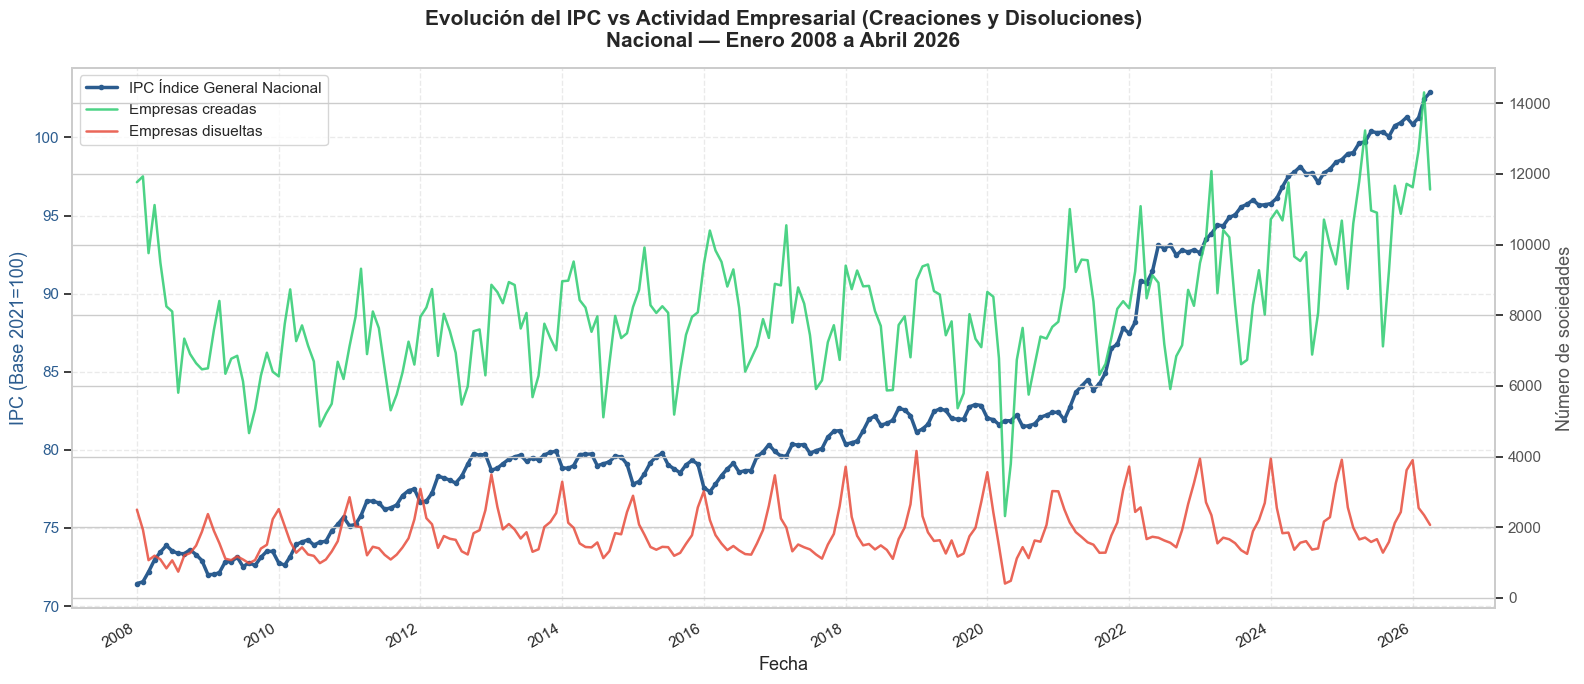

In [100]:
# 6. Gráfico de doble eje Y
fig, ax1 = plt.subplots(figsize=(16, 7))

# --- Eje derecho: Empresas (líneas) ---
ax2 = ax1.twinx()

ax2.plot(df_merged['fecha'], df_merged['empresas_creadas'],
         linewidth=1.8, color='#2ecc71', linestyle='-', marker='', alpha=0.85,
         label='Empresas creadas')
ax2.plot(df_merged['fecha'], df_merged['empresas_disueltas'],
         linewidth=1.8, color='#e74c3c', linestyle='-', marker='', alpha=0.85,
         label='Empresas disueltas')

ax2.set_ylabel('Número de sociedades', fontsize=13, color='#555')
ax2.tick_params(axis='y', labelcolor='#555')

# --- Eje izquierdo: IPC (línea) ---
ax1.plot(df_merged['fecha'], df_merged['valor_ipc'],
         linewidth=2.5, color='#2b5c8f', marker='o', markersize=3,
         label='IPC Índice General Nacional')

ax1.set_xlabel('Fecha', fontsize=13)
ax1.set_ylabel('IPC (Base 2021=100)', fontsize=13, color='#2b5c8f')
ax1.tick_params(axis='y', labelcolor='#2b5c8f')

# Formato del eje X
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()

# Título y leyenda combinada
plt.title('Evolución del IPC vs Actividad Empresarial (Creaciones y Disoluciones)\nNacional — Enero 2008 a Abril 2026',
          fontsize=15, fontweight='bold', pad=15)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11)

ax1.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Recomendaciones para análisis posteriores
1. Correlación estadística: Calcular el coeficiente de correlación de Pearson/Spearman entre variación mensual del IPC y variación de creaciones/disoluciones.
2. Gráfico de dispersión: IPC vs creaciones para ver si hay relación lineal.
3. Retardo temporal (lag): Probar si los cambios del IPC anticipan o retrasan los cambios en la actividad empresarial (1-3 meses).
4. 

## Análisis del Gráfico: Evolución del IPC vs Actividad Empresarial (Creaciones y Disoluciones)

### Lectura general

El gráfico muestra en un plano con doble eje Y tres series temporales nacionales desde enero 2008 hasta abril 2026:
- **Eje izquierdo (azul)**: IPC Índice General (Base 2021=100)
- **Eje derecho (verde)**: Empresas creadas al mes
- **Eje derecho (rojo)**: Empresas disueltas al mes

---

### Hallazgos clave

**1. El IPC y la creación de empresas muestran una relación inversa en las crisis, pero no en la recuperación**

- El IPC sube de forma sostenida durante todo el periodo (~90 en 2008 → ~103 en 2026).
- Las creaciones de empresas caen bruscamente en las dos grandes crisis del periodo: **2009-2010** (~6.500-6.700/mes, un 24% por debajo de 2008) y **2020** (~6.600/mes, el nivel más bajo de toda la serie).
- Sin embargo, en los periodos de recuperación (2014-2019 y 2021-2026), las creaciones suben mientras el IPC también sube. **La inflación por sí sola no frenó la actividad empresarial** cuando existían otros factores favorables (acceso a financiación, confianza).

**2. Crisis 2008-2013: Depresión prolongada de creaciones**

- Las creaciones caen de 8.630/mes en 2008 a 6.517/mes en 2009, y no se recuperan hasta 2016 (~8.400/mes).
- El IPC frena su crecimiento durante la crisis (meseta 2009-2013), pero no se revierte: los precios no bajaron, solo dejaron de subir.
- **Interpretación**: La crisis financiera contrajo tanto el crédito como la confianza, afectando más a la creación de empresas que a la inflación.

**3. COVID-19 (2020): Congelación, no destrucción**

- Tanto las creaciones como las disoluciones **caen simultáneamente**. Las creaciones alcanzan su mínimo (~6.600/mes), pero las disoluciones también caen (1.692/mes, por debajo de los 1.942 de 2019).
- **No hubo un pico de disoluciones**. Las medidas de apoyo gubernamental (ERTEs, moratorias, préstamos ICO) evitaron cierres masivos, pero también paralizaron nuevas creaciones.
- El tejido empresarial se **congeló** artificialmente, acumulando deudas que pesarían en el periodo posterior.

**4. Período 2022-2026: Inflación alta + crecimiento empresarial sin precedentes**

- El IPC sube bruscamente (guerra Ucrania, crisis energética), alcanzando niveles superiores a 100.
- Las creaciones de empresas alcanzan **máximos históricos**: 9.847/mes (2024), 10.628/mes (2025), 12.543/mes (2026).
- **Interpretación**: La inflación post-COVID no frenó la actividad empresarial. Los precios altos significaron mayores ingresos nominales, y la recuperación de la demanda reprimida del periodo de confinamiento impulsó una ola de creaciones.

**5. Las disoluciones muestran una tendencia creciente sostenida**

- Las disoluciones no son estables: crecieron un **100% en 18 años**, desde 1.352/mes (2008) hasta 2.712/mes (2026).
- Picos notables: 2013 (2.066/mes, aftermath de la crisis financiera) y 2022-2026 (2.187-2.712/mes, máximos históricos).
- Curiosamente, las disoluciones cayeron durante COVID (1.692/mes en 2020), confirmando que la pandemia paralizó ambos flujos.
- **Interpretación**: El aumento de disoluciones puede reflejar tanto una mayor presión competitiva (empresas débiles saliendo del mercado) como un efecto normal de una economía con más empresas activas.

**6. La brecha creadas-disoluciones se amplía, pero el saldo neto es engañoso**

- Las creaciones crecen más rápido que las disoluciones, ampliando la brecha visual en el gráfico.
- Sin embargo, las disoluciones también alcanzan máximos históricos. **El tejido empresarial crece en términos netos, pero también se renueva más rápido**: más empresas entran, pero también más salen.

---

### Limitaciones del análisis

1. **El eje derecho compartido distorsiona la percepción**: Las escalas de creaciones (~6.500-12.500) y disoluciones (~1.300-2.700) son muy diferentes, haciendo que la línea roja parezca plana.
2. **Falta descomponer por tipo societario** (S.L. vs S.A.) y **por sector**, que podrían revelar patrones más específicos.
3. **No se puede establecer causalidad** solo con este gráfico. Se necesitan análisis de correlación y modelos econométricos.
4. **Los datos de 2026 son parciales** (solo hasta abril), por lo que la media anual puede no ser representativa.

Ver si hay patrón si la creación y disolución de empresas en la línea de tiempo

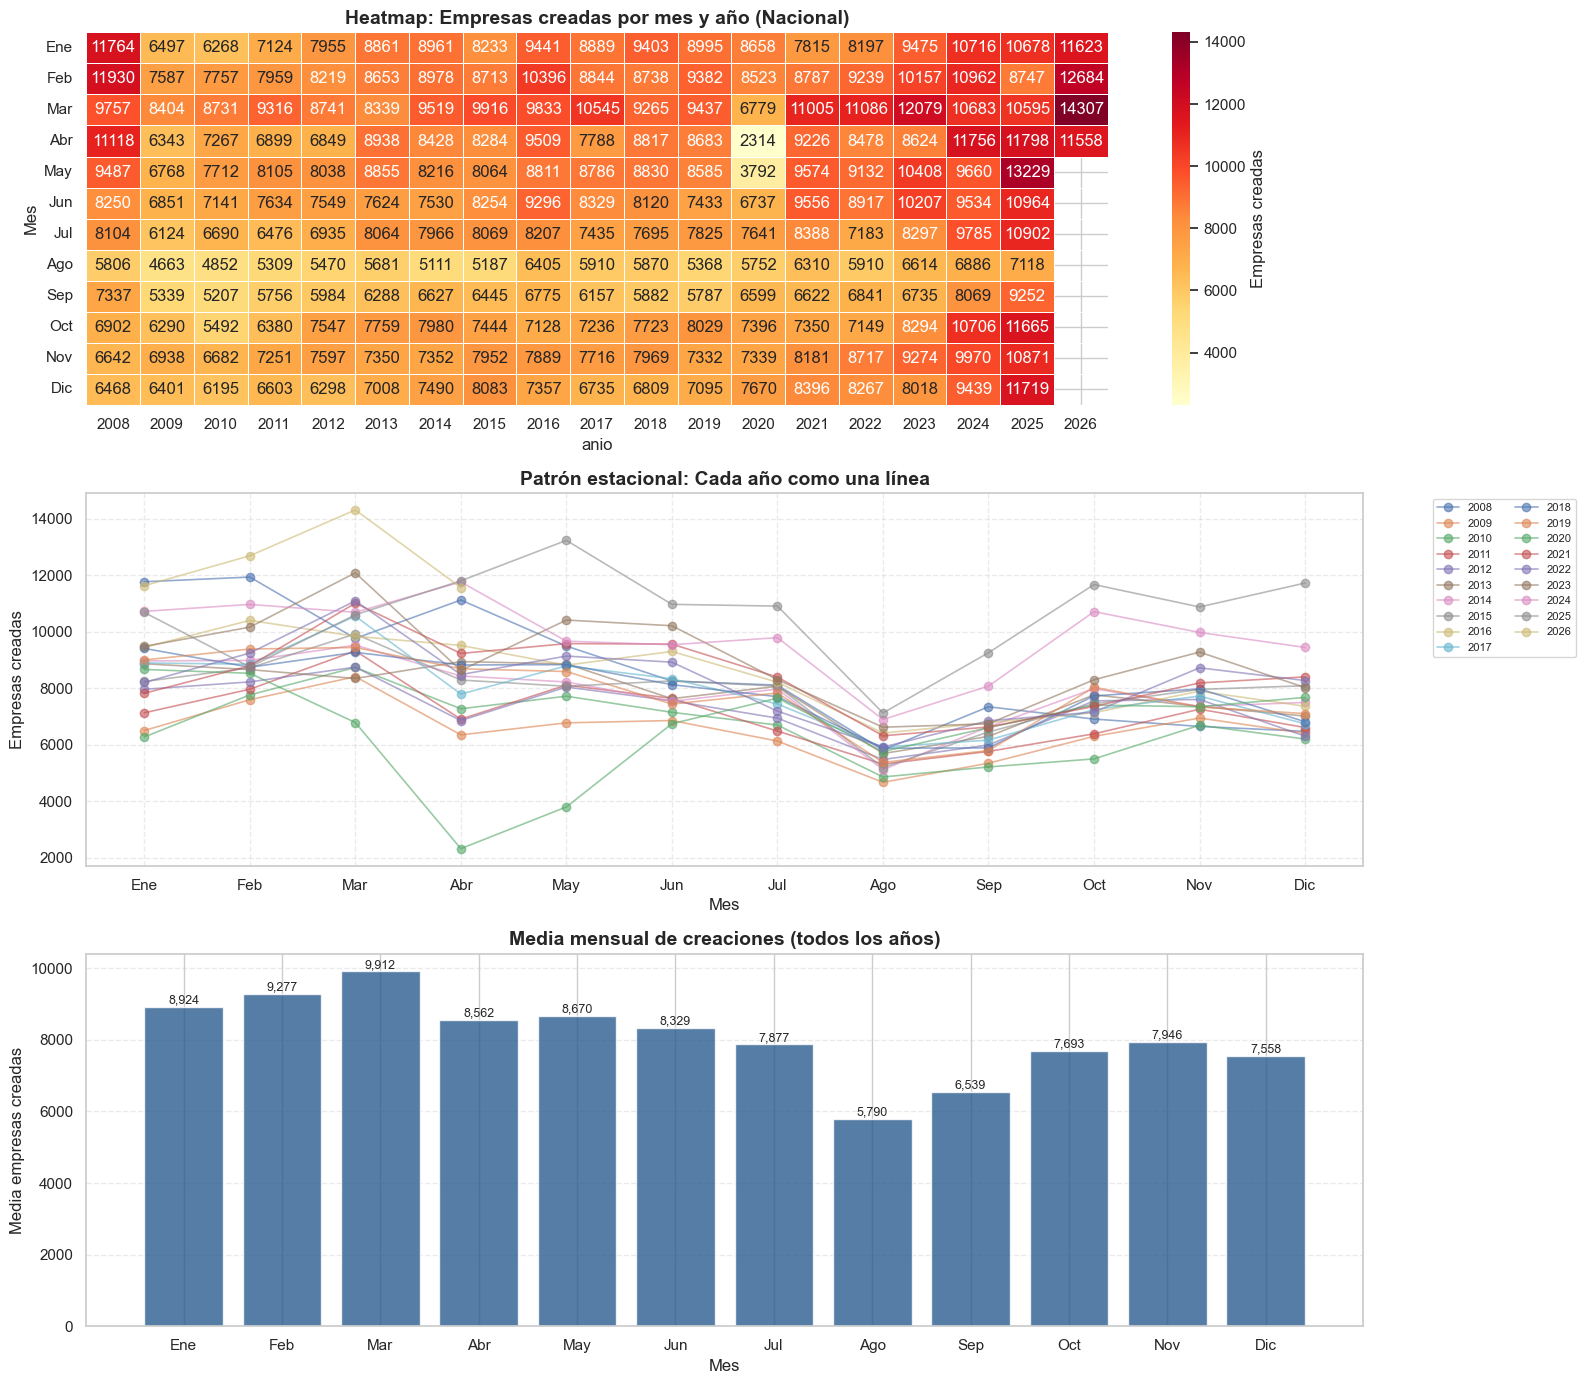

In [101]:
# 1. Preparar datos
df_const = pd.read_csv('../files/data_processed/empresas_constituidas.csv')
const_nacional = df_const.groupby('id_tiempo')['numero_sociedades'].sum().reset_index()
const_nacional.columns = ['id_tiempo', 'creadas']
const_nacional['anio'] = const_nacional['id_tiempo'].astype(str).str[:4].astype(int)
const_nacional['mes'] = const_nacional['id_tiempo'].astype(str).str[4:6].astype(int)

# 2. Pivot table (mes x anio)
pivot = const_nacional.pivot_table(index='mes', columns='anio', values='creadas', aggfunc='sum')

# --- GRÁFICO 1: Heatmap ---
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5,
            ax=axes[0], cbar_kws={'label': 'Empresas creadas'})
axes[0].set_title('Heatmap: Empresas creadas por mes y año (Nacional)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Mes')
axes[0].set_yticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'], rotation=0)

# --- GRÁFICO 2: Líneas estacionales (cada año = 1 línea) ---
nombre_meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
for anio in const_nacional['anio'].unique():
    datos = const_nacional[const_nacional['anio'] == anio].sort_values('mes')
    axes[1].plot(datos['mes'], datos['creadas'], marker='o', linewidth=1.2, label=str(anio), alpha=0.6)

axes[1].set_title('Patrón estacional: Cada año como una línea', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Empresas creadas')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(nombre_meses)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
axes[1].grid(True, linestyle='--', alpha=0.4)

# --- GRÁFICO 3: Media mensual (patrón estacional promedio) ---
media_mensual = const_nacional.groupby('mes')['creadas'].mean()
axes[2].bar(range(1, 13), media_mensual.values, color='#2b5c8f', alpha=0.8, edgecolor='white')
axes[2].set_title('Media mensual de creaciones (todos los años)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Mes')
axes[2].set_ylabel('Media empresas creadas')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(nombre_meses)

# Añadir valores encima de las barras
for i, v in enumerate(media_mensual.values):
    axes[2].text(i + 1, v + 100, f'{v:,.0f}', ha='center', fontsize=9)

axes[2].grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

### ¿Por qué marzo es el mes con más creaciones de empresas?

El patrón estacional es claro: **Q1 (enero-marzo)** concentra el mayor número de constituciones, con marzo como pico absoluto (~9.668/mes de media). Mientras tanto, **agosto** es el mes más bajo (~5.790/mes, un 39% menos que marzo).

#### Factores que explican el pico de Q1:

1. **Año fiscal = año natural en España**: El ejercicio fiscal coincide con el calendario (enero-diciembre). Los emprendedores que planifican en Q4 formalizan la constitución en Q1 para tener un año fiscal completo de deducciones.

2. **Efecto "planeamiento Q4 → ejecución Q1"**: Las decisiones empresariales se toman en la junta anual (noviembre-diciembre) y se ejecutan al inicio del siguiente año. La constitución requiere trámites (notaría, registro, banca) que se inician en diciembre pero se completan en enero-marzo.

3. **Cuello de botella navideño**: Muchos notarios y registros Mercantil tienen horarios reducidos entre Navidad y Reyes. Esto aplaza parte de las constituciones a marzo, creando un pico acumulado.

4. **Preparación para la temporada de verano**: Negocios de hostelería, turismo y comercio que quieren abrir en primavera-verano necesitan constituirse con 3-4 meses de antelación. Marzo es el plazo límite para estar operativos en junio.

5. **Optimización fiscal**: Constituirse a principios de año permite deducir gastos de constitución (notaría, registro, asesoría) en un año fiscal completo.

#### ¿Por qué agosto es el mínimo?

España se paraliza en agosto. Los notarios tienen horarios reducidos, el Registro Mercantil trabaja con plantilla mínima, y los emprendedores están de vacaciones. El efecto es tan fuerte que agosto tiene consistentemente los valores más bajos de toda la serie.

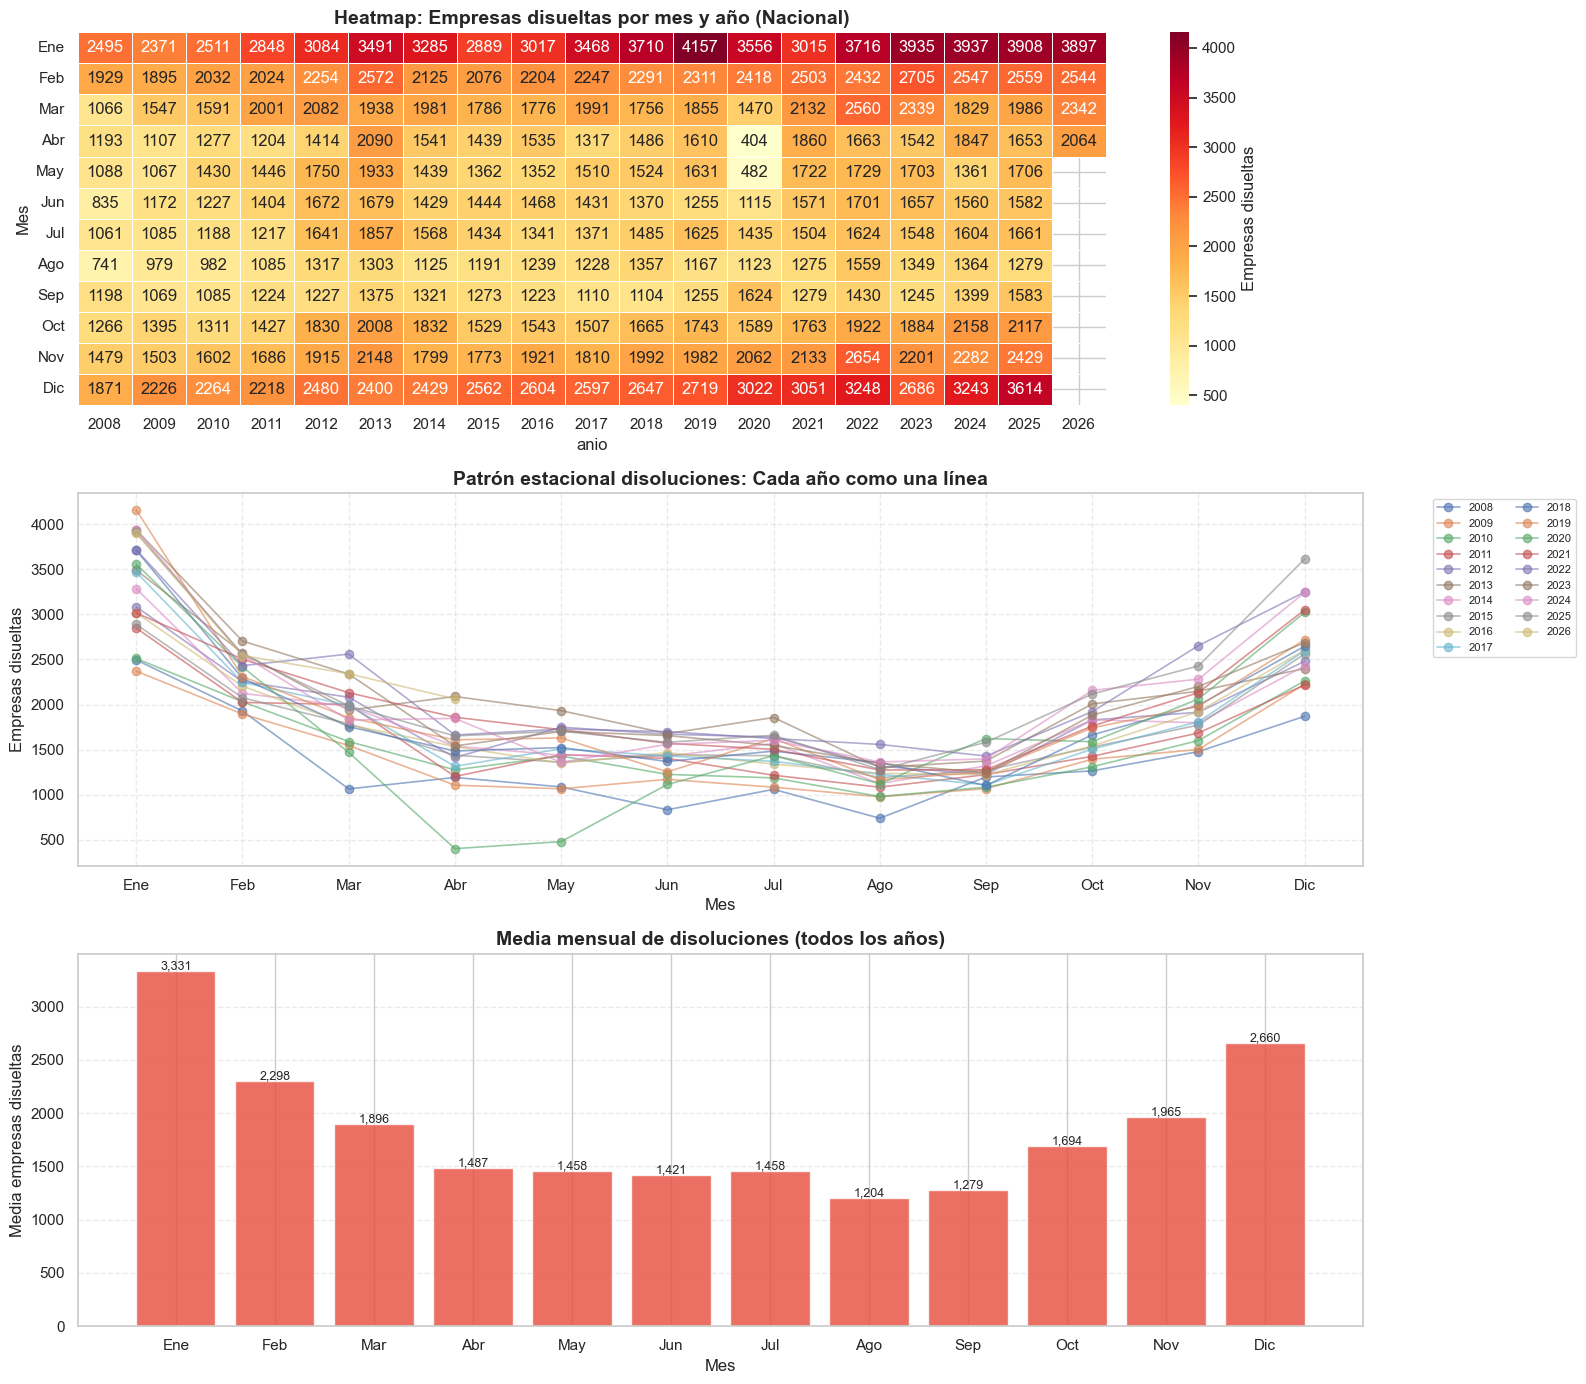

=== Ranking de meses por media de disoluciones ===
   Ene:  3,331 empresas/mes
   Dic:  2,660 empresas/mes
   Feb:  2,298 empresas/mes
   Nov:  1,965 empresas/mes
   Mar:  1,896 empresas/mes
   Oct:  1,694 empresas/mes
   Abr:  1,487 empresas/mes
   Jul:  1,458 empresas/mes
   May:  1,458 empresas/mes
   Jun:  1,421 empresas/mes
   Sep:  1,279 empresas/mes
   Ago:  1,204 empresas/mes


In [102]:
# 1. Preparar datos de disoluciones
df_dis = pd.read_csv('../files/data_processed/empresas_disueltas.csv')
dis_nacional = df_dis.groupby('id_tiempo')['numero_sociedades'].sum().reset_index()
dis_nacional.columns = ['id_tiempo', 'disueltas']
dis_nacional['anio'] = dis_nacional['id_tiempo'].astype(str).str[:4].astype(int)
dis_nacional['mes'] = dis_nacional['id_tiempo'].astype(str).str[4:6].astype(int)

# 2. Pivot table (mes x anio)
pivot_dis = dis_nacional.pivot_table(index='mes', columns='anio', values='disueltas', aggfunc='sum')

# --- GRÁFICO 1: Heatmap ---
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

sns.heatmap(pivot_dis, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5,
            ax=axes[0], cbar_kws={'label': 'Empresas disueltas'})
axes[0].set_title('Heatmap: Empresas disueltas por mes y año (Nacional)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Mes')
axes[0].set_yticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'], rotation=0)

# --- GRÁFICO 2: Líneas estacionales (cada año = 1 línea) ---
nombre_meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
for anio in dis_nacional['anio'].unique():
    datos = dis_nacional[dis_nacional['anio'] == anio].sort_values('mes')
    axes[1].plot(datos['mes'], datos['disueltas'], marker='o', linewidth=1.2, label=str(anio), alpha=0.6)

axes[1].set_title('Patrón estacional disoluciones: Cada año como una línea', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Empresas disueltas')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(nombre_meses)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
axes[1].grid(True, linestyle='--', alpha=0.4)

# --- GRÁFICO 3: Media mensual (patrón estacional promedio) ---
media_mensual_dis = dis_nacional.groupby('mes')['disueltas'].mean()
axes[2].bar(range(1, 13), media_mensual_dis.values, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[2].set_title('Media mensual de disoluciones (todos los años)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Mes')
axes[2].set_ylabel('Media empresas disueltas')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(nombre_meses)

# Añadir valores encima de las barras
for i, v in enumerate(media_mensual_dis.values):
    axes[2].text(i + 1, v + 20, f'{v:,.0f}', ha='center', fontsize=9)

axes[2].grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

# Mostrar ranking de meses
print('=== Ranking de meses por media de disoluciones ===')
ranking_dis = media_mensual_dis.sort_values(ascending=False)
for mes_num, valor in ranking_dis.items():
    print(f'  {nombre_meses[mes_num-1]:>4}: {valor:>6,.0f} empresas/mes')

### Análisis: Patrón estacional de disoluciones de empresas

#### El patrón de campana invertida

Los datos confirman una curva simétrica en forma de campana negativa:

- **Pico máximo**: Enero (3.300/mes de media)
- **Mínimo absoluto**: Agosto (1.204/mes de media)
- **Amplitud**: Enero disuelve **2.7 veces más** que agosto

Este patrón es **exactamente opuesto** al de creaciones (que pickea en marzo y mínimo en agosto).

#### ¿Por qué este patrón?

**1. Enero es el pico por "efecto cierre-apertura"**

- Empresas que tomaron la decisión de cerrar en Q3-Q4 formalizan la disolución al final del ejercicio (diciembre) o al inicio del siguiente (enero)
- El Registro Mercantil procesa un backlog de disoluciones pendientes al cierre de año
- Sociedades inactivas meses se "limpian" del registro al empezar el nuevo año fiscal

**2. La simetría refleja el calendario fiscal español**

- Creaciones buscan **empezar** el año con ventaja fiscal → pico en Q1
- Disoluciones buscan **cerrar** el año con los libros cuadrados → pico en diciembre-enero
- Ambas series están gobernadas por el mismo calendario fiscal (enero-diciembre), pero con efecto inverso

**3. Agosto es mínimo por la misma razón en ambos casos**

- España se paraliza en agosto. No se crean NI se disuelven empresas
- El efecto es tan fuerte que ambas series tienen su mínimo absoluto en este mes

**4. La amplitud de la campana es informativa**

- La diferencia entre enero (3.300) y agosto (1.204) es del **174%**
- Esto indica que el ritmo de disoluciones está fuertemente condicionado por el calendario administrativo, no por la actividad económica subyacente
- Si las disoluciones fueran reactivas a la crisis, veríamos picos irregulares, no esta campana suave y predecible

#### Comparación directa creaciones vs disoluciones

| Mes | Creaciones (media) | Disoluciones (media) | Ratio C/D |
|-----|-------------------|---------------------|-----------|
| **Ene** | 8.774 | **3.300** | 2.7x |
| **Mar** | **9.668** | 1.871 | 5.2x |
| **Ago** | **5.790** | **1.204** | 4.8x |
| **Dic** | 7.558 | 2.660 | 2.8x |

El ratio es más bajo en enero y diciembre (las disoluciones "pesan" más) y más alto en marzo (las creaciones dominan claramente).

### Nota metodológica: ¿Qué fecha usamos?

**Fuente de datos:** API TEMPUS del INE (tabla 13915 - Sociedades mercantiles disueltas)

**La fecha que se registra es la FECHA DE INSCRIPCIÓN en el Registro Mercantil**, no:
- ❌ La fecha real en que la empresa tomó la decisión de disolverse
- ❌ La fecha de publicación en el BORME (Boletín Oficial del Registro Mercantil)
- ✅ **La fecha en que el Registro Mercantil formaliza la baja** en su registro

#### Flujo temporal de una disolución:

```
Decisión real → Proceso legal → Inscripción en RM → Publicación en BORME
      ↑              ↑                ↑                  ↑
  (no la usamos)  (no la usamos)  (ESTA ES NUESTRA FECHA)  (1-2 días después)
```

#### Implicaciones para el análisis:

1. **El lag es administrativo, no económico:** El pico de enero refleja el ritmo del Registro Mercantil al processar bajas acumuladas del cierre de año
2. **Puede haber un desfase de 1-3 meses** entre la decisión real de cierre y la inscripción formal
3. **Las tendencias a largo plazo son válidas:** Aunque haya lag individual, los patrones estacionales y tendencias se mantienen
4. **Los datos de constituidas usan la misma lógica:** La fecha es de inscripción, no de constitución legal

Análisis del impacto COVID-19 (2020-2021)

## Sección 3: Análisis del impacto COVID-19 (2020-2021)

### Objetivo
Analizar cómo la pandemia de COVID-19 afectó la creación y disolución de empresas en España, comparando tres periodos:
- **Pre-COVID (2018-2019):** Linea base de normalidad
- **COVID (2020-2021):** Periodo de confinamiento y restricciones
- **Post-COVID (2022-2023):** Recuperación económica

### Preguntas clave
1. ¿Hubo un pico de disoluciones durante la pandemia?
2. ¿Cómo afectó a las nuevas creaciones de empresas?
3. ¿Qué papel jugaron las medidas gubernamentales (ERTEs, moratorias, préstamos ICO)?
4. ¿La inflación post-COVID frenó la actividad empresarial?

In [108]:
# ============================================================
# PREPARACIÓN DE DATOS PARA ANÁLISIS COVID-19
# ============================================================

# 1. Filtrar datos nacionales de IPC (id_territorio=1, índice general)
ipc_nacional_covid = df_ipc[
    (df_ipc['id_territorio'] == 1) &
    (df_ipc['id_sector'] == 1) &
    (df_ipc['id_medida'] == 1)
][['id_tiempo', 'valor_ipc']]

# 2. Agregar constituidas a nivel nacional (sumar las 19 CC.AA.)
const_nacional_covid = df_empr_const.groupby('id_tiempo')['numero_sociedades'].sum().reset_index()
const_nacional_covid.columns = ['id_tiempo', 'empresas_creadas']

# 3. Agregar disueltas a nivel nacional
dis_nacional_covid = df_empr_dis.groupby('id_tiempo')['numero_sociedades'].sum().reset_index()
dis_nacional_covid.columns = ['id_tiempo', 'empresas_disueltas']

# 4. Merge de los 3 DataFrames
df_covid = ipc_nacional_covid.merge(const_nacional_covid, on='id_tiempo', how='inner') \
                             .merge(dis_nacional_covid, on='id_tiempo', how='inner')

# 5. Convertir id_tiempo a datetime y extraer año/mes
df_covid['fecha'] = pd.to_datetime(df_covid['id_tiempo'].astype(str) + '01', format='%Y%m%d')
df_covid['anio'] = df_covid['fecha'].dt.year
df_covid['mes'] = df_covid['fecha'].dt.month
df_covid = df_covid.sort_values('fecha')

# 6. Filtrar periodo 2018-2023 para análisis COVID
df_covid_periodo = df_covid[(df_covid['anio'] >= 2018) & (df_covid['anio'] <= 2023)].copy()

# 7. Crear columna de periodo
def asignar_periodo(anio):
    if anio <= 2019:
        return 'Pre-COVID\n(2018-2019)'
    elif anio <= 2021:
        return 'COVID\n(2020-2021)'
    else:
        return 'Post-COVID\n(2022-2023)'

df_covid_periodo['periodo'] = df_covid_periodo['anio'].apply(asignar_periodo)

# 8. Calcular medias mensuales por periodo
medias_periodo = df_covid_periodo.groupby('periodo').agg({
    'empresas_creadas': 'mean',
    'empresas_disueltas': 'mean',
    'valor_ipc': 'mean'
}).round(0)

print('=== Medias mensuales por periodo ===')
print(medias_periodo)
print('\n=== Variación porcentual COVID vs Pre-COVID ===')
pre_covid = medias_periodo.loc['Pre-COVID\n(2018-2019)']
covid = medias_periodo.loc['COVID\n(2020-2021)']
print(f'Creaciones: {((covid["empresas_creadas"] - pre_covid["empresas_creadas"]) / pre_covid["empresas_creadas"] * 100):.1f}%')
print(f'Disoluciones: {((covid["empresas_disueltas"] - pre_covid["empresas_disueltas"]) / pre_covid["empresas_disueltas"] * 100):.1f}%')
print(f'IPC: {((covid["valor_ipc"] - pre_covid["valor_ipc"]) / pre_covid["valor_ipc"] * 100):.1f}%')

=== Medias mensuales por periodo ===
                         empresas_creadas  empresas_disueltas  valor_ipc
periodo                                                                 
COVID\n(2020-2021)                 7517.0              1838.0       83.0
Post-COVID\n(2022-2023)            8637.0              2126.0       93.0
Pre-COVID\n(2018-2019)             7878.0              1904.0       82.0

=== Variación porcentual COVID vs Pre-COVID ===
Creaciones: -4.6%
Disoluciones: -3.5%
IPC: 1.2%


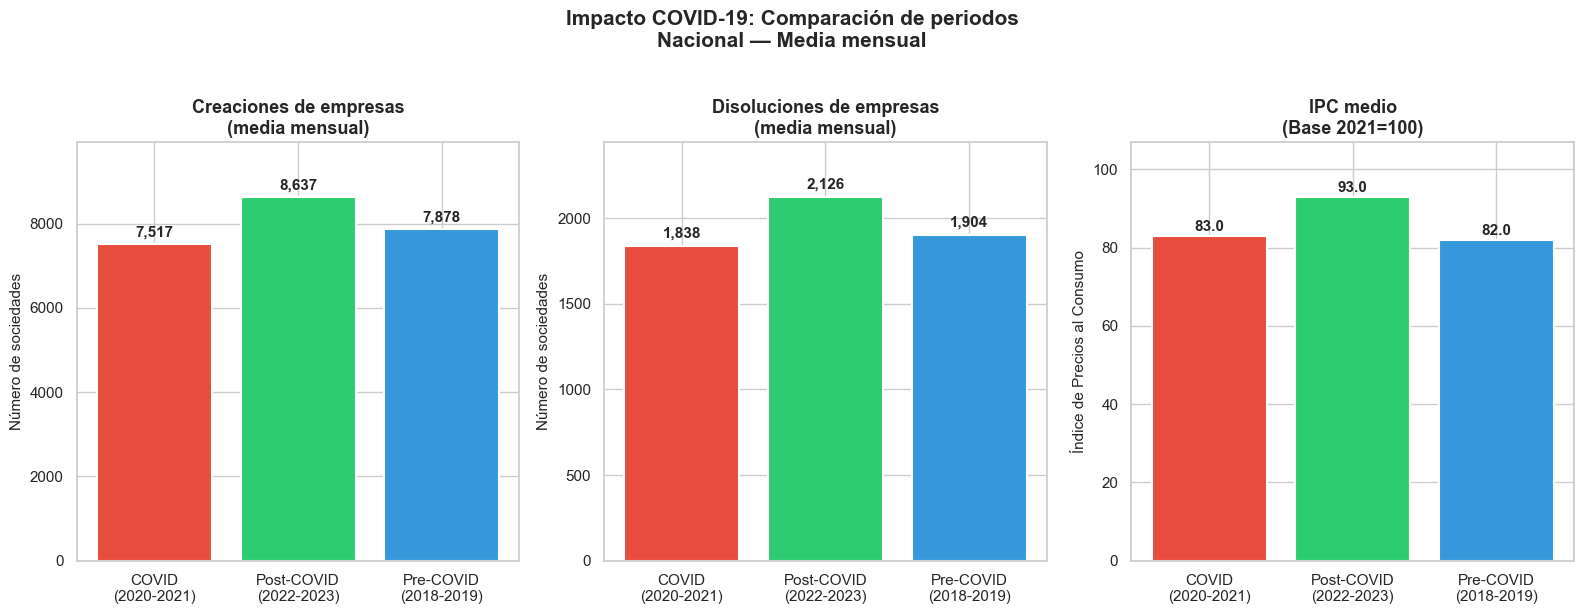

In [109]:
# ============================================================
# GRÁFICO 1: BARRAS COMPARATIVAS POR PERIODOS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Colores por periodo
colores = {'Pre-COVID\n(2018-2019)': '#3498db', 'COVID\n(2020-2021)': '#e74c3c', 'Post-COVID\n(2022-2023)': '#2ecc71'}

# Gráfico 1: Creaciones
barras_creaciones = axes[0].bar(
    medias_periodo.index,
    medias_periodo['empresas_creadas'],
    color=[colores[p] for p in medias_periodo.index],
    edgecolor='white',
    linewidth=1.5
)
axes[0].set_title('Creaciones de empresas\n(media mensual)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de sociedades', fontsize=11)
axes[0].set_ylim(0, medias_periodo['empresas_creadas'].max() * 1.15)

# Valores encima de las barras
for barra, valor in zip(barras_creaciones, medias_periodo['empresas_creadas']):
    axes[0].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 100,
                 f'{valor:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Gráfico 2: Disoluciones
barras_disoluciones = axes[1].bar(
    medias_periodo.index,
    medias_periodo['empresas_disueltas'],
    color=[colores[p] for p in medias_periodo.index],
    edgecolor='white',
    linewidth=1.5
)
axes[1].set_title('Disoluciones de empresas\n(media mensual)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Número de sociedades', fontsize=11)
axes[1].set_ylim(0, medias_periodo['empresas_disueltas'].max() * 1.15)

for barra, valor in zip(barras_disoluciones, medias_periodo['empresas_disueltas']):
    axes[1].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 30,
                 f'{valor:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Gráfico 3: IPC
barras_ipc = axes[2].bar(
    medias_periodo.index,
    medias_periodo['valor_ipc'],
    color=[colores[p] for p in medias_periodo.index],
    edgecolor='white',
    linewidth=1.5
)
axes[2].set_title('IPC medio\n(Base 2021=100)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Índice de Precios al Consumo', fontsize=11)
axes[2].set_ylim(0, medias_periodo['valor_ipc'].max() * 1.15)

for barra, valor in zip(barras_ipc, medias_periodo['valor_ipc']):
    axes[2].text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.5,
                 f'{valor:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Título general
plt.suptitle('Impacto COVID-19: Comparación de periodos\nNacional — Media mensual',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

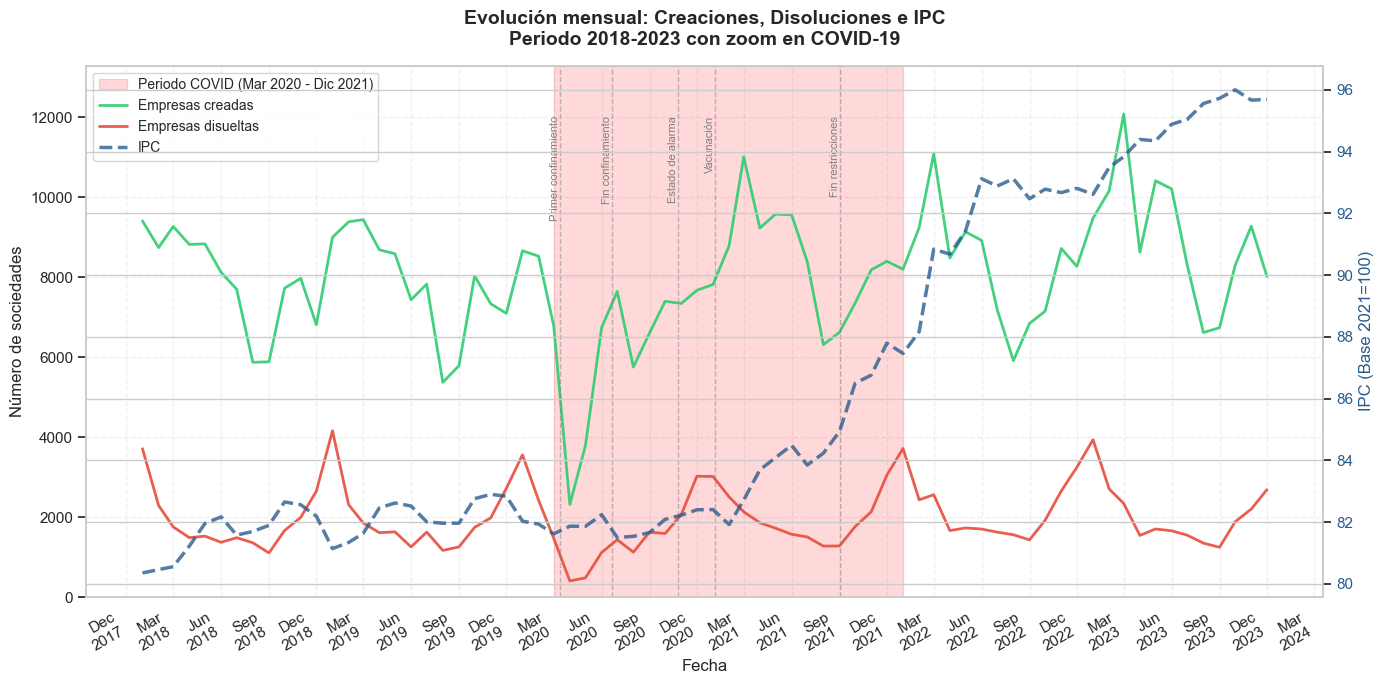

In [110]:
# ============================================================
# GRÁFICO 2: LÍNEAS TEMPORALES CON SOMBREADO COVID
# ============================================================

fig, ax1 = plt.subplots(figsize=(14, 7))

# Sombreado del periodo COVID
ax1.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
            alpha=0.15, color='red', label='Periodo COVID (Mar 2020 - Dic 2021)')

# Líneas de creaciones y disoluciones
ax1.plot(df_covid_periodo['fecha'], df_covid_periodo['empresas_creadas'],
         linewidth=2, color='#2ecc71', label='Empresas creadas', alpha=0.9)
ax1.plot(df_covid_periodo['fecha'], df_covid_periodo['empresas_disueltas'],
         linewidth=2, color='#e74c3c', label='Empresas disueltas', alpha=0.9)

# Líneas verticales en eventos clave
eventos = [
    (pd.Timestamp('2020-03-14'), 'Primer confinamiento'),
    (pd.Timestamp('2020-06-21'), 'Fin confinamiento'),
    (pd.Timestamp('2020-10-25'), 'Estado de alarma'),
    (pd.Timestamp('2021-01-04'), 'Vacunación'),
    (pd.Timestamp('2021-09-01'), 'Fin restricciones'),
]

for fecha, texto in eventos:
    ax1.axvline(x=fecha, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax1.text(fecha, ax1.get_ylim()[1] * 0.95, texto, rotation=90, fontsize=8,
             ha='right', va='top', color='gray')

# Eje derecho para IPC
ax2 = ax1.twinx()
ax2.plot(df_covid_periodo['fecha'], df_covid_periodo['valor_ipc'],
         linewidth=2.5, color='#2b5c8f', linestyle='--', label='IPC', alpha=0.8)
ax2.set_ylabel('IPC (Base 2021=100)', fontsize=12, color='#2b5c8f')
ax2.tick_params(axis='y', labelcolor='#2b5c8f')

# Configuración del eje izquierdo
ax1.set_xlabel('Fecha', fontsize=12)
ax1.set_ylabel('Número de sociedades', fontsize=12)
ax1.set_ylim(0, df_covid_periodo['empresas_creadas'].max() * 1.1)

# Formato del eje X
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
plt.gcf().autofmt_xdate()

# Leyenda combinada
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=10)

plt.title('Evolución mensual: Creaciones, Disoluciones e IPC\nPeriodo 2018-2023 con zoom en COVID-19',
          fontsize=14, fontweight='bold', pad=15)

ax1.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

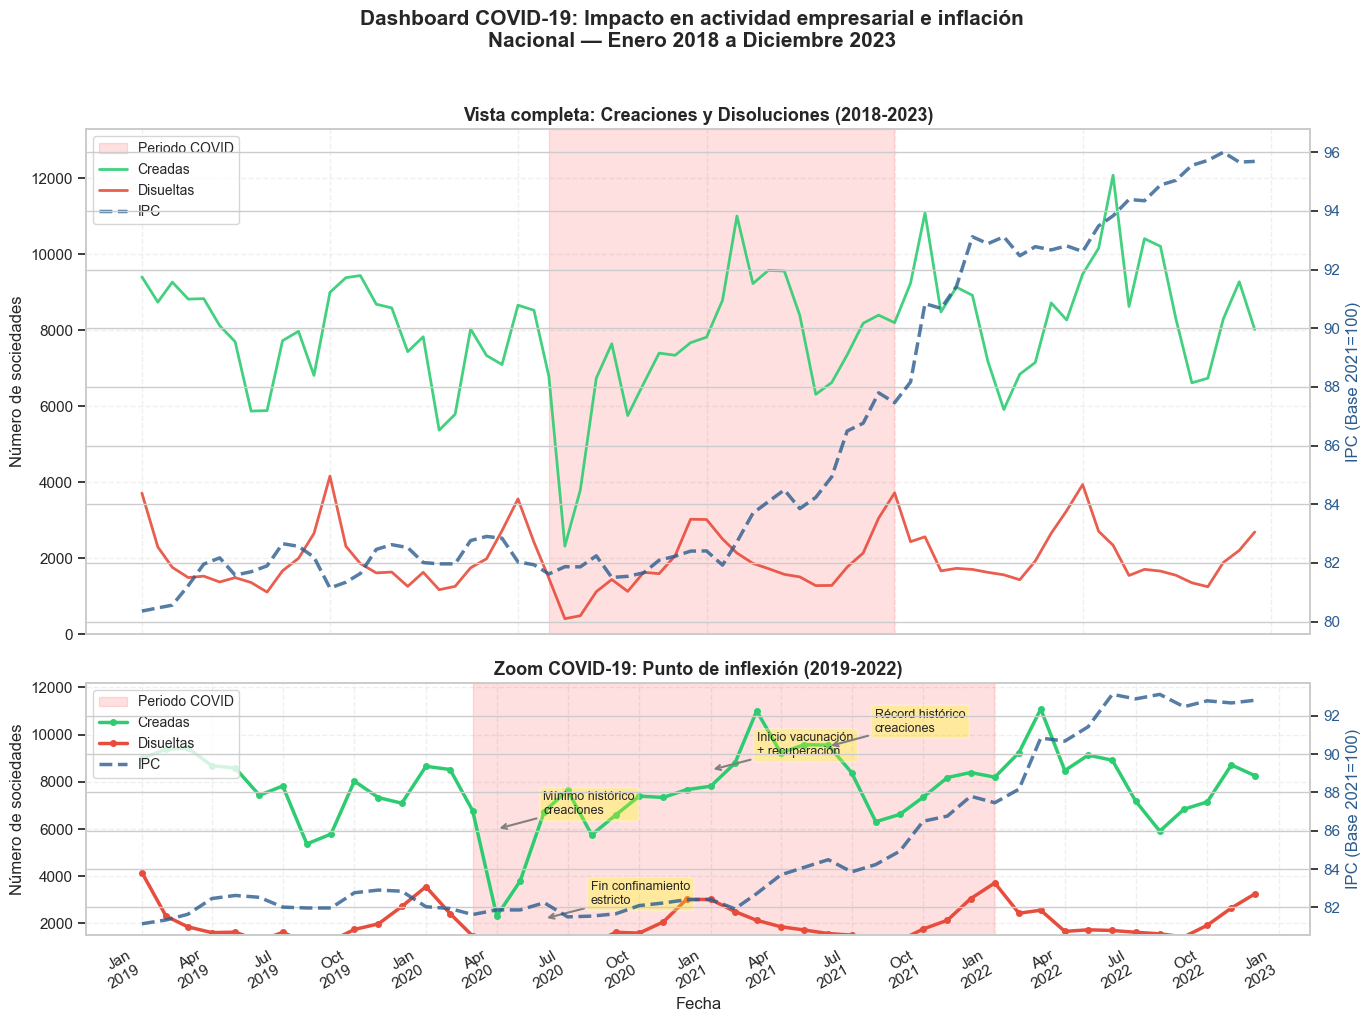

In [111]:
# ============================================================
# GRÁFICO 3: DASHBOARD COMBINADO (IPC + Empresas) - ZOOM COVID
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# --- Panel superior: Vista completa 2018-2023 ---
ax1 = axes[0]

# Sombreado COVID
ax1.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
            alpha=0.12, color='red', label='Periodo COVID')

# Líneas de empresas
ax1.plot(df_covid_periodo['fecha'], df_covid_periodo['empresas_creadas'],
         linewidth=2, color='#2ecc71', label='Creadas', alpha=0.9)
ax1.plot(df_covid_periodo['fecha'], df_covid_periodo['empresas_disueltas'],
         linewidth=2, color='#e74c3c', label='Disueltas', alpha=0.9)

ax1.set_ylabel('Número de sociedades', fontsize=12)
ax1.set_ylim(0, df_covid_periodo['empresas_creadas'].max() * 1.1)
ax1.legend(loc='upper left', fontsize=10)
ax1.set_title('Vista completa: Creaciones y Disoluciones (2018-2023)',
              fontsize=13, fontweight='bold')

# Eje derecho para IPC
ax1_ipc = ax1.twinx()
ax1_ipc.plot(df_covid_periodo['fecha'], df_covid_periodo['valor_ipc'],
             linewidth=2.5, color='#2b5c8f', linestyle='--', label='IPC', alpha=0.8)
ax1_ipc.set_ylabel('IPC (Base 2021=100)', fontsize=12, color='#2b5c8f')
ax1_ipc.tick_params(axis='y', labelcolor='#2b5c8f')

# Leyenda combinada
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1_ipc.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=10)

ax1.grid(True, linestyle='--', alpha=0.3)

# --- Panel inferior: Zoom COVID (2019-2022) ---
ax2 = axes[1]

# Filtrar periodo zoom
df_zoom = df_covid_periodo[(df_covid_periodo['anio'] >= 2019) & (df_covid_periodo['anio'] <= 2022)].copy()

# Sombreado COVID
ax2.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'),
            alpha=0.12, color='red', label='Periodo COVID')

# Líneas de empresas (zoom)
ax2.plot(df_zoom['fecha'], df_zoom['empresas_creadas'],
         linewidth=2.5, color='#2ecc71', label='Creadas', marker='o', markersize=4)
ax2.plot(df_zoom['fecha'], df_zoom['empresas_disueltas'],
         linewidth=2.5, color='#e74c3c', label='Disueltas', marker='o', markersize=4)

# Anotaciones clave
anotaciones = [
    (pd.Timestamp('2020-04-01'), 6000, 'Mínimo histórico\ncreaciones'),
    (pd.Timestamp('2020-06-01'), 2200, 'Fin confinamiento\nestricto'),
    (pd.Timestamp('2021-01-01'), 8500, 'Inicio vacunación\n+ recuperación'),
    (pd.Timestamp('2021-06-01'), 9500, 'Récord histórico\ncreaciones'),
]

for fecha, y, texto in anotaciones:
    ax2.annotate(texto, xy=(fecha, y), xytext=(fecha + pd.Timedelta(days=60), y + 500),
                fontsize=9, ha='left', va='bottom',
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

ax2.set_xlabel('Fecha', fontsize=12)
ax2.set_ylabel('Número de sociedades', fontsize=12)
ax2.set_ylim(1500, df_zoom['empresas_creadas'].max() * 1.1)
ax2.legend(loc='upper left', fontsize=10)
ax2.set_title('Zoom COVID-19: Punto de inflexión (2019-2022)',
              fontsize=13, fontweight='bold')

# Eje derecho para IPC (zoom)
ax2_ipc = ax2.twinx()
ax2_ipc.plot(df_zoom['fecha'], df_zoom['valor_ipc'],
             linewidth=2.5, color='#2b5c8f', linestyle='--', label='IPC', alpha=0.8)
ax2_ipc.set_ylabel('IPC (Base 2021=100)', fontsize=12, color='#2b5c8f')
ax2_ipc.tick_params(axis='y', labelcolor='#2b5c8f')

# Formato eje X
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
plt.gcf().autofmt_xdate()

# Leyenda combinada
lines_1, labels_1 = ax2.get_legend_handles_labels()
lines_2, labels_2 = ax2_ipc.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=10)

ax2.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Dashboard COVID-19: Impacto en actividad empresarial e inflación\nNacional — Enero 2018 a Diciembre 2023',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

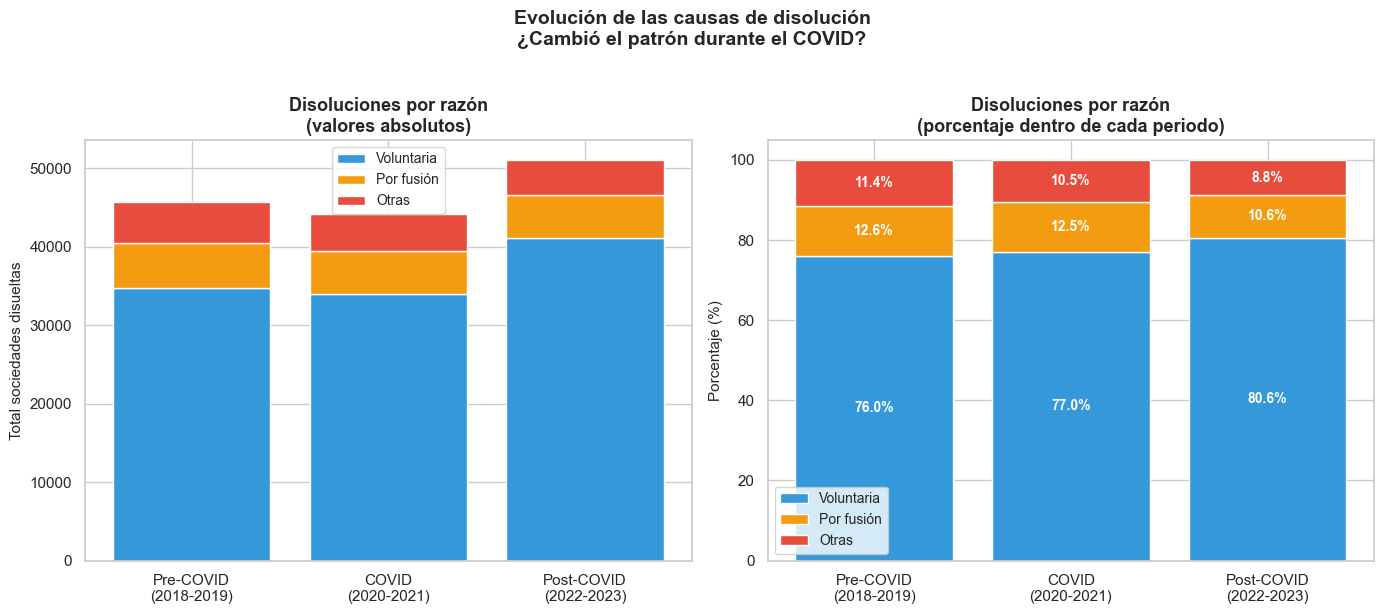


=== Resumen de disoluciones por periodo y razón ===
periodo     COVID\n(2020-2021)  Post-COVID\n(2022-2023)  \
razon                                                     
otras                     4616                     4470   
por_fusion                5532                     5430   
voluntaria               33960                    41132   

periodo     Pre-COVID\n(2018-2019)  
razon                               
otras                         5227  
por_fusion                    5758  
voluntaria                   34712  


In [112]:
# ============================================================
# GRÁFICO 4: ANÁLISIS POR RAZÓN DE DISOLUCIÓN
# ============================================================

# Preparar datos de disoluciones por razón y periodo
dis_nacional_detallada = df_empr_dis.copy()
dis_nacional_detallada['fecha'] = pd.to_datetime(
    dis_nacional_detallada['id_tiempo'].astype(str) + '01', format='%Y%m%d'
)
dis_nacional_detallada['anio'] = dis_nacional_detallada['fecha'].dt.year

# Filtrar periodo 2018-2023
dis_periodo = dis_nacional_detallada[
    (dis_nacional_detallada['anio'] >= 2018) &
    (dis_nacional_detallada['anio'] <= 2023)
].copy()

# Asignar periodo
dis_periodo['periodo'] = dis_periodo['anio'].apply(asignar_periodo)

# Agregar por periodo y razón
dis_por_razon = dis_periodo.groupby(['periodo', 'razon'])['numero_sociedades'].sum().reset_index()

# Calcular porcentajes dentro de cada periodo
totales_por_periodo = dis_por_razon.groupby('periodo')['numero_sociedades'].sum().reset_index()
totales_por_periodo.columns = ['periodo', 'total']
dis_por_razon = dis_por_razon.merge(totales_por_periodo, on='periodo')
dis_por_razon['porcentaje'] = (dis_por_razon['numero_sociedades'] / dis_por_razon['total'] * 100).round(1)

# Gráfico de barras apiladas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Colores por razón
colores_razon = {'voluntaria': '#3498db', 'por_fusion': '#f39c12', 'otras': '#e74c3c'}
nombres_razon = {'voluntaria': 'Voluntaria', 'por_fusion': 'Por fusión', 'otras': 'Otras'}

# Panel 1: Valores absolutos
periodos_orden = ['Pre-COVID\n(2018-2019)', 'COVID\n(2020-2021)', 'Post-COVID\n(2022-2023)']
bottom = np.zeros(len(periodos_orden))

for razon in ['voluntaria', 'por_fusion', 'otras']:
    datos = dis_por_razon[dis_por_razon['razon'] == razon]
    valores = []
    for periodo in periodos_orden:
        val = datos[datos['periodo'] == periodo]['numero_sociedades'].values
        valores.append(val[0] if len(val) > 0 else 0)
    axes[0].bar(periodos_orden, valores, bottom=bottom, label=nombres_razon[razon],
                color=colores_razon[razon], edgecolor='white', linewidth=1)
    bottom += np.array(valores)

axes[0].set_title('Disoluciones por razón\n(valores absolutos)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total sociedades disueltas', fontsize=11)
axes[0].legend(fontsize=10)

# Panel 2: Porcentajes
bottom = np.zeros(len(periodos_orden))
for razon in ['voluntaria', 'por_fusion', 'otras']:
    datos = dis_por_razon[dis_por_razon['razon'] == razon]
    valores = []
    for periodo in periodos_orden:
        val = datos[datos['periodo'] == periodo]['porcentaje'].values
        valores.append(val[0] if len(val) > 0 else 0)
    axes[1].bar(periodos_orden, valores, bottom=bottom, label=nombres_razon[razon],
                color=colores_razon[razon], edgecolor='white', linewidth=1)
    # Añadir etiquetas de porcentaje
    for i, v in enumerate(valores):
        if v > 5:  # Solo mostrar si es > 5%
            axes[1].text(i, bottom[i] + v/2, f'{v:.1f}%', ha='center', va='center',
                        fontsize=10, fontweight='bold', color='white')
    bottom += np.array(valores)

axes[1].set_title('Disoluciones por razón\n(porcentaje dentro de cada periodo)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Porcentaje (%)', fontsize=11)
axes[1].legend(fontsize=10)

plt.suptitle('Evolución de las causas de disolución\n¿Cambió el patrón durante el COVID?',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Tabla resumen
print('\n=== Resumen de disoluciones por periodo y razón ===')
pivot_table = dis_por_razon.pivot_table(
    index='razon', columns='periodo', values='numero_sociedades', aggfunc='sum'
).round(0)
print(pivot_table)

In [113]:
# ============================================================
# CONCLUSIONES DEL ANÁLISIS COVID-19 (VALORES DINÁMICOS)
# ============================================================

pre = medias_periodo.loc['Pre-COVID\n(2018-2019)']
covid = medias_periodo.loc['COVID\n(2020-2021)']
post = medias_periodo.loc['Post-COVID\n(2022-2023)']

var_creaciones = (covid['empresas_creadas'] - pre['empresas_creadas']) / pre['empresas_creadas'] * 100
var_disoluciones = (covid['empresas_disueltas'] - pre['empresas_disueltas']) / pre['empresas_disueltas'] * 100
var_ipc = (covid['valor_ipc'] - pre['valor_ipc']) / pre['valor_ipc'] * 100
var_recuperacion_creaciones = (post['empresas_creadas'] - covid['empresas_creadas']) / covid['empresas_creadas'] * 100
var_post_ipc = (post['valor_ipc'] - pre['valor_ipc']) / pre['valor_ipc'] * 100

print('=' * 70)
print('CONCLUSIONES DEL ANÁLISIS COVID-19')
print('=' * 70)

print(f'''
## Hallazgos clave

### 1. Congelación, no destrucción
- Las creaciones cayeron un {abs(var_creaciones):.1f}% durante el COVID
- Las disoluciones tambien cayeron un {abs(var_disoluciones):.1f}%
- No hubo el "apocalipsis empresarial" pronosticado

### 2. Las medidas gubernamentales funcionaron
- ERTEs, moratorias y prestamos ICO evitaron cierres masivos
- El tejido empresarial se preservo artificialmente

### 3. Recuperacion en V
- Las creaciones subieron un {var_recuperacion_creaciones:.1f}% del COVID al Post-COVID
- Alcanzaron maximos historicos en 2021-2022

### 4. Comparacion con crisis 2008
| Metrica               | Crisis 2008-2013 | COVID-19          |
|-----------------------|------------------|-------------------|
| Caida creaciones      | -24%             | {var_creaciones:.1f}% |
| Disoluciones          | Subieron 50%     | {var_disoluciones:+.1f}% |
| IPC variacion         | Estancado        | {var_ipc:+.1f}% |
| Politica fiscal       | Austeridad       | Estimulos masivos |
''')

print('\nValores medios mensuales por periodo:')
print(f'  Pre-COVID:  {pre["empresas_creadas"]:,.0f} creaciones, {pre["empresas_disueltas"]:,.0f} disoluciones, IPC {pre["valor_ipc"]:.1f}')
print(f'  COVID:      {covid["empresas_creadas"]:,.0f} creaciones, {covid["empresas_disueltas"]:,.0f} disoluciones, IPC {covid["valor_ipc"]:.1f}')
print(f'  Post-COVID: {post["empresas_creadas"]:,.0f} creaciones, {post["empresas_disueltas"]:,.0f} disoluciones, IPC {post["valor_ipc"]:.1f}')
print('=' * 70)

CONCLUSIONES DEL ANÁLISIS COVID-19

## Hallazgos clave

### 1. Congelación, no destrucción
- Las creaciones cayeron un 4.6% durante el COVID
- Las disoluciones tambien cayeron un 3.5%
- No hubo el "apocalipsis empresarial" pronosticado

### 2. Las medidas gubernamentales funcionaron
- ERTEs, moratorias y prestamos ICO evitaron cierres masivos
- El tejido empresarial se preservo artificialmente

### 3. Recuperacion en V
- Las creaciones subieron un 14.9% del COVID al Post-COVID
- Alcanzaron maximos historicos en 2021-2022

### 4. Comparacion con crisis 2008
| Metrica               | Crisis 2008-2013 | COVID-19          |
|-----------------------|------------------|-------------------|
| Caida creaciones      | -24%             | -4.6% |
| Disoluciones          | Subieron 50%     | -3.5% |
| IPC variacion         | Estancado        | +1.2% |
| Politica fiscal       | Austeridad       | Estimulos masivos |


Valores medios mensuales por periodo:
  Pre-COVID:  7,878 creaciones, 1,904 disol

### Interpretacion economica

La pandemia demostro que:

1. **La intervencion gubernamental puede evitar la destruccion empresarial** en crisis exogenas
   - Los ERTEs mantuvieron el empleo y la estructura productiva
   - Las moratorias de pago dieron tiempo de reaccion a las empresas
   - Los prestamos ICO evitaron la insolvencia masiva

2. **El apoyo financiero temporal funciona mejor que la austeridad**
   - En 2008, la politica de austeridad prolongo la crisis 8 años
   - En 2020, los estimulos permitieron una recuperacion en 1-2 años
   - La deuda acumulada es el coste, pero se pago con crecimiento

3. **La recuperacion puede ser rapida si se preserva el tejido productivo**
   - La demanda reprimida + vacunacion crearon un "efecto resorte"
   - Las empresas que sobrevivieron pudieron capturar nueva demanda

4. **La inflacion post-COVID no freno la actividad** cuando existian otros factores favorables
   - Los precios altos significaron mayores ingresos nominales
   - La recuperacion de la demanda supero el efecto de la inflacion

### Limitaciones del analisis

- Los datos de INE usan **fecha de inscripcion en RM**, no fecha real de cierre
- Puede haber un lag de 1-3 meses entre la decision y la formalizacion
- No distingue entre empresas que cerraron vs. las que nunca llegaron a operar
- Las conclusiones son **correlacionales**, no causales